In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [17]:
# 2. Load Dataset

df = pd.read_csv(r"C:\Users\Pranav Shinde\Desktop\Superstore_Analysis.csv")

In [5]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Standard Class,Corporate,United States,Lafayette,Indiana,47905,Central,Technology,Copiers,17499.95,5,0.0,8399.9760
1,First Class,Consumer,United States,Seattle,Washington,98115,West,Technology,Copiers,13999.96,4,0.0,6719.9808
2,Standard Class,Consumer,United States,Newark,Delaware,19711,East,Technology,Copiers,10499.97,3,0.0,5039.9856
3,Standard Class,Consumer,United States,Detroit,Michigan,48205,Central,Office Supplies,Binders,9892.74,13,0.0,4946.3700
4,Standard Class,Consumer,United States,Minneapolis,Minnesota,55407,Central,Office Supplies,Binders,9449.95,5,0.0,4630.4755


In [16]:
# 3. Data Overview

df.shape

(9977, 13)

In [7]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1013.4+ KB


In [9]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [15]:
# 4. Data Cleaning
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(9977, 13)

In [14]:
# 5. Missing Value Analysis
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [18]:
# 6. Sales Analysis
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64


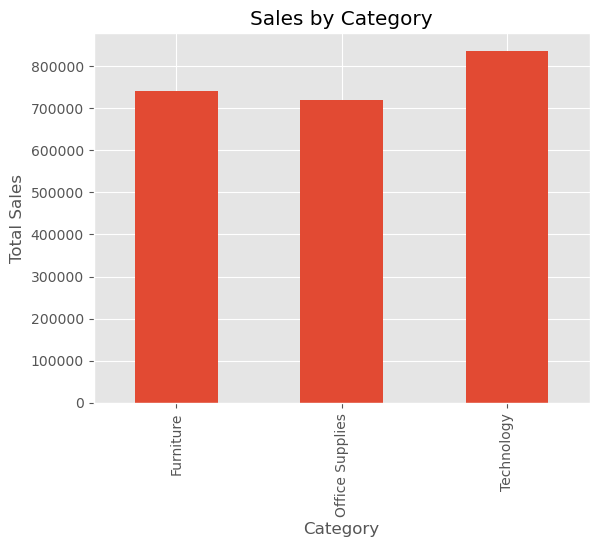

In [19]:
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

In [20]:
# 7. Profit Analysis
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64


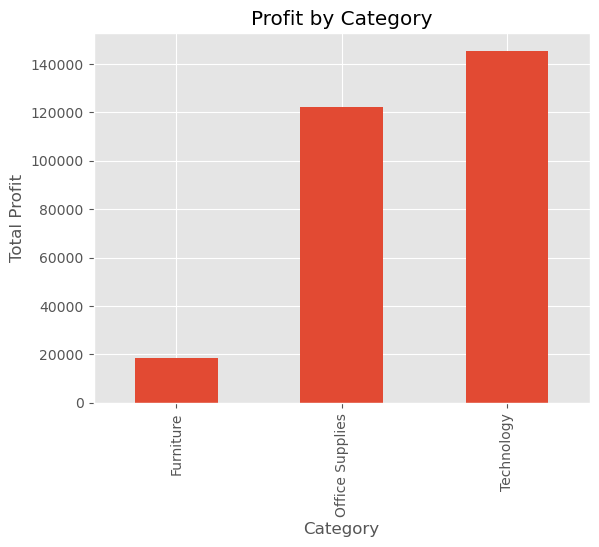

In [21]:
category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.show()

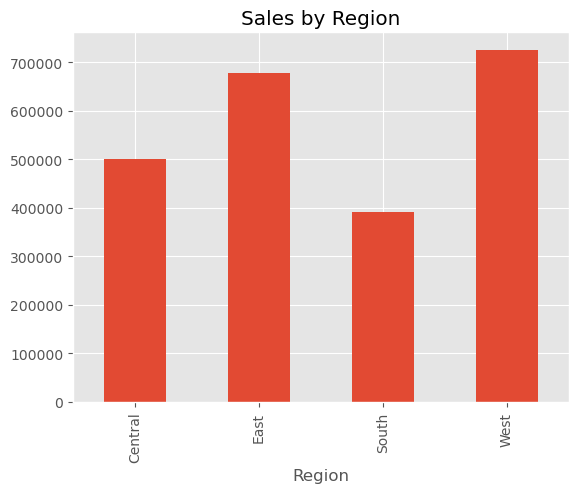

In [22]:
# 8. Regional Analysis
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.show()

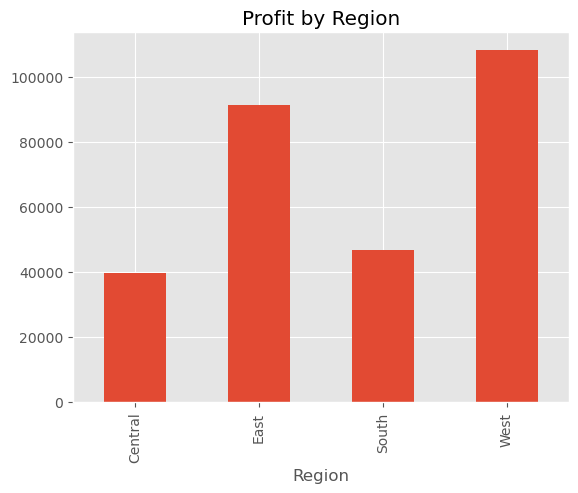

In [23]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.show()

In [24]:
# 9. Product Analysis
top_subcat = (
    df.groupby('Sub-Category')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_subcat

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

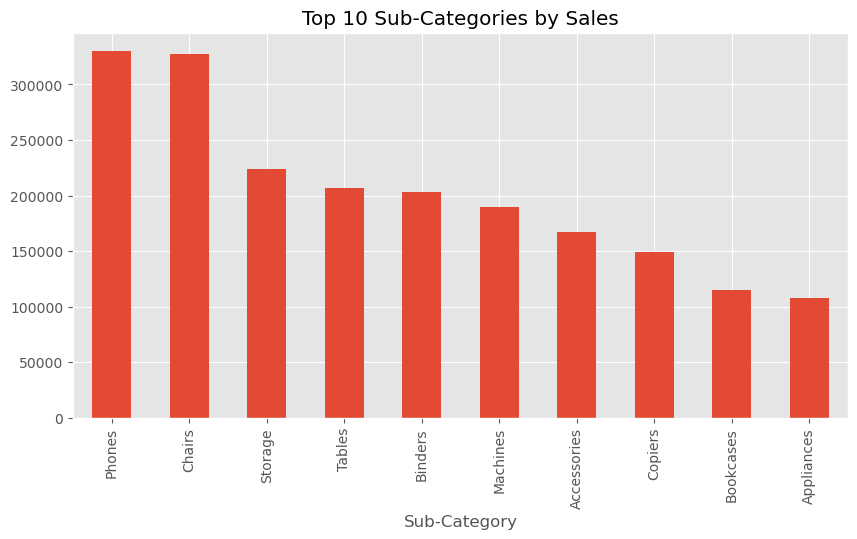

In [25]:
top_subcat.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Sub-Categories by Sales')
plt.show()

In [26]:
# 10. Correlation Analysis
corr = df[['Sales','Profit','Quantity','Discount']].corr()

corr

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479067,0.200722,-0.028311
Profit,0.479067,1.000000,0.066211,-0.219662
Quantity,0.200722,0.066211,1.000000,0.008678
Discount,-0.028311,-0.219662,0.008678,1.000000


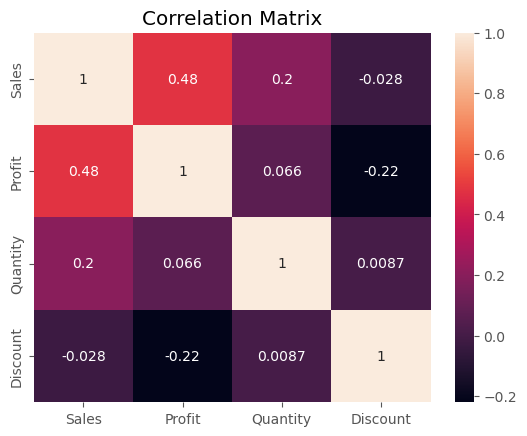

In [27]:
sns.heatmap(corr, annot=True)

plt.title('Correlation Matrix')

plt.show()

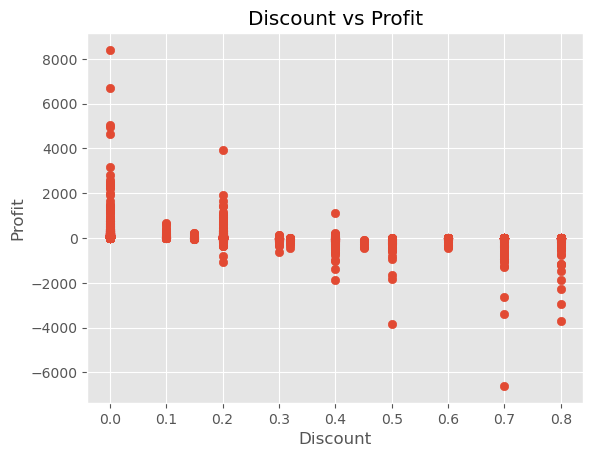

In [28]:
# 11. Discount vs Profit Analysis
plt.scatter(df['Discount'], df['Profit'])

plt.xlabel('Discount')
plt.ylabel('Profit')

plt.title('Discount vs Profit')

plt.show()

In [ ]:
# 12. Key Business Insights

1. Technology generated the highest sales revenue.
2. Technology generated the highest profit.
3. West region contributed the highest profit.
4. Copiers were among the top-performing sub-categories.
5. Higher discounts negatively impacted profitability.
6. Sales and Profit showed a positive relationship.